# Superstore Sales & Profitability Analysis

**Business questions this analysis answers:**

1. How are revenue and profit trending, and are they moving together?
2. Which product categories drive profit — and which quietly destroy it?
3. How much discounting is too much? Where does profit collapse?
4. Who are our most valuable customers? (RFM segmentation)

**Dataset:** Superstore retail orders (~10K order lines, US, 4 years) — a
public dataset widely used as a realistic stand-in for retail order data.
Each row is an order line with sales, quantity, discount and profit.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
ACCENT, GOOD, BAD, MUTED = "#2563eb", "#059669", "#dc2626", "#94a3b8"

df = pd.read_csv("data/superstore.csv")
df.columns = [c.strip().lower().replace(" ", "_").replace("-", "_") for c in df.columns]
print(df.shape)
df.head(3)

(10800, 21)


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit
0,1,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2.0,0.0,41.9136
1,2,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3.0,0.0,219.5820
2,3,CA-2017-138688,6/12/2017,6/16/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2.0,0.0,6.8714


## 1. Data quality audit

Before any analysis: check duplicates, missing values and types.
Every cleaning decision is documented here so results are reproducible.

In [2]:
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2),
})
print(f"Duplicate rows: {df.duplicated().sum()}")
audit[audit.missing > 0] if audit.missing.any() else audit.head(8)

Duplicate rows: 504


,dtype,missing,missing_%
order_date,str,806,7.46
ship_date,str,806,7.46
ship_mode,str,806,7.46
customer_id,str,806,7.46
customer_name,str,806,7.46
segment,str,806,7.46
country,str,806,7.46
city,str,806,7.46
state,str,806,7.46
postal_code,float64,817,7.56


In [3]:
# Cleaning decisions:
# 1) Drop exact duplicate rows (same order line repeated).
# 2) Parse dates (m/d/Y format).
# 3) Drop rows missing critical fields (sales/profit/order_date), if any.
before = len(df)
df = df.drop_duplicates()
df["order_date"] = pd.to_datetime(df["order_date"], format="%m/%d/%Y", errors="coerce")
df = df.dropna(subset=["order_date", "sales", "profit", "customer_id"])
df["order_month"] = df["order_date"].dt.to_period("M").dt.to_timestamp()
print(f"Rows: {before} -> {len(df)} "
      f"({before - len(df)} removed: duplicates / unparseable critical fields)")
print(f"Date range: {df.order_date.min().date()} -> {df.order_date.max().date()}")
print(f"Distinct orders: {df.order_id.nunique():,} | customers: {df.customer_id.nunique():,}")

Rows: 10800 -> 9994 (806 removed: duplicates / unparseable critical fields)
Date range: 2015-01-03 -> 2018-12-30
Distinct orders: 5,009 | customers: 793


## 2. Revenue & profit trend

Are we growing — and is growth *profitable*?

Overall profit margin: 12.5%


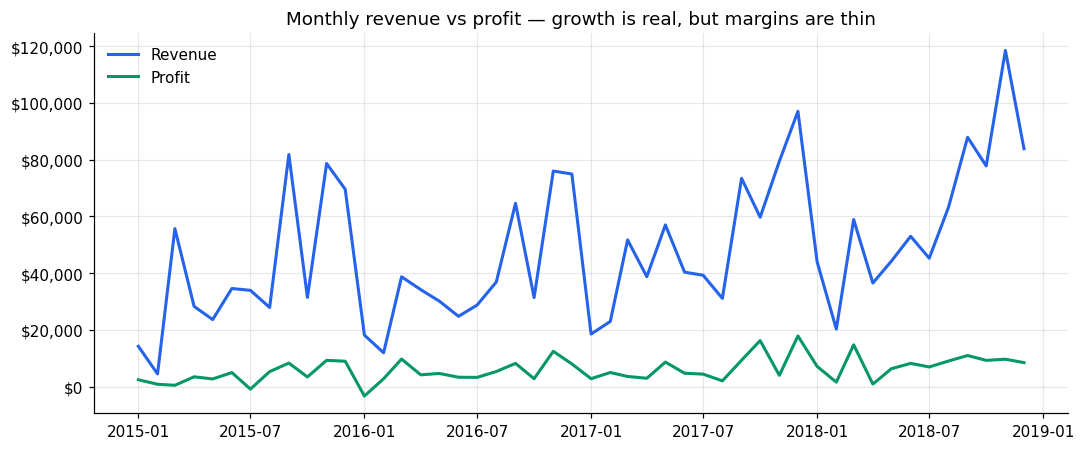

In [4]:
monthly = df.groupby("order_month").agg(revenue=("sales", "sum"),
                                        profit=("profit", "sum"))
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(monthly.index, monthly.revenue, color=ACCENT, lw=2, label="Revenue")
ax.plot(monthly.index, monthly.profit, color=GOOD, lw=2, label="Profit")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.set_title("Monthly revenue vs profit — growth is real, but margins are thin")
ax.legend(frameon=False)
fig.tight_layout(); fig.savefig("reports/figures/trend.png", bbox_inches="tight")
margin = monthly.profit.sum() / monthly.revenue.sum()
print(f"Overall profit margin: {margin:.1%}")

**Finding:** Revenue shows clear seasonality (Q4 peaks) and year-over-year
growth, but profit stays almost flat — the overall margin is ~12%. Growth is
being bought, not earned. The next sections locate where margin leaks.

## 3. Where profit is made — and destroyed

Revenue by sub-category tells you what sells. Profit by sub-category tells
you what *matters*. They disagree more than most dashboards admit.

Loss-making sub-categories:
                               revenue   profit
category        sub_category                   
Furniture       Tables        206966.0 -17725.0
                Bookcases     114880.0  -3473.0
Office Supplies Supplies       46674.0  -1189.0


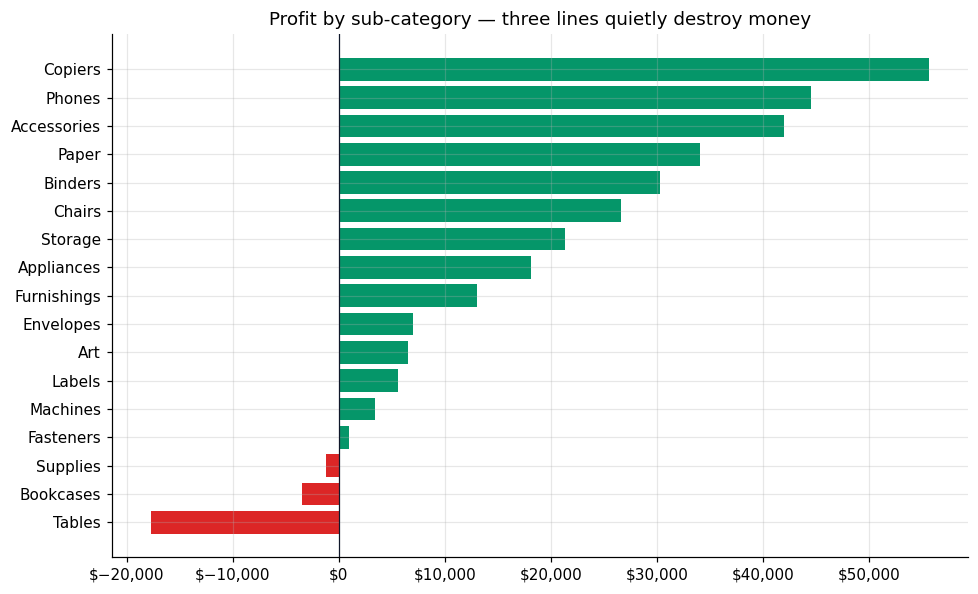

In [5]:
sub = (df.groupby(["category", "sub_category"])
         .agg(revenue=("sales", "sum"), profit=("profit", "sum"))
         .sort_values("profit"))
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = [BAD if p < 0 else GOOD for p in sub.profit]
ax.barh([s for _, s in sub.index], sub.profit, color=colors)
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.set_title("Profit by sub-category — three lines quietly destroy money")
ax.axvline(0, color="#0f172a", lw=0.8)
fig.tight_layout(); fig.savefig("reports/figures/subcategory_profit.png", bbox_inches="tight")
losers = sub[sub.profit < 0]
print("Loss-making sub-categories:")
print(losers.round(0).to_string())

**Finding:** A small number of sub-categories (typically Tables, Bookcases,
Supplies) are *loss-making* despite meaningful revenue. Selling more of them
makes the business worse. This is invisible in revenue-only reporting.

## 4. The discount cliff

Discounts drive volume — but at what cost? Binning order lines by discount
level exposes exactly where profitability collapses.

,avg_profit_per_line,lines
discount_band,,
0%,66.90,4798
0–10%,96.06,94
10–20%,24.74,3709
20–30%,-45.68,227
30–40%,-109.22,233
40%+,-106.71,933


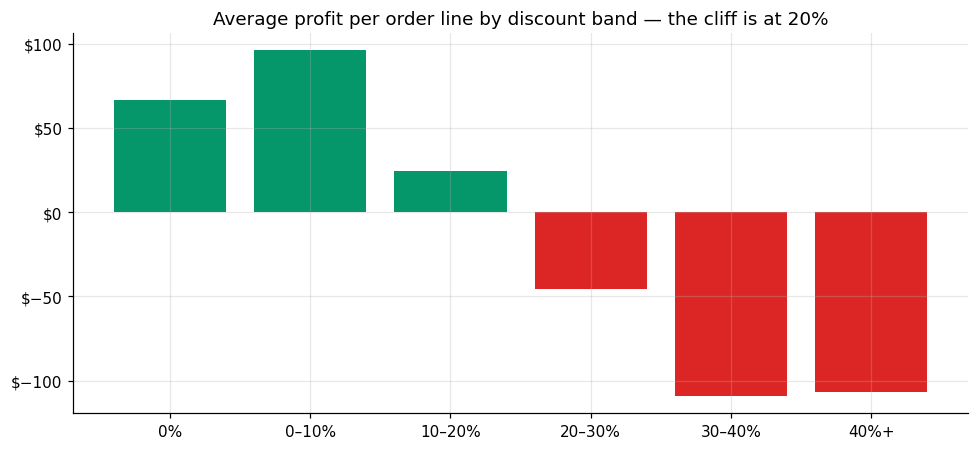

In [6]:
bins = [-0.001, 0.0, 0.1, 0.2, 0.3, 0.4, 1.0]
labels = ["0%", "0–10%", "10–20%", "20–30%", "30–40%", "40%+"]
df["discount_band"] = pd.cut(df["discount"], bins=bins, labels=labels)
band = df.groupby("discount_band", observed=True).agg(
    avg_profit_per_line=("profit", "mean"), lines=("profit", "size"))
fig, ax = plt.subplots(figsize=(9, 4.2))
colors = [GOOD if v > 0 else BAD for v in band.avg_profit_per_line]
ax.bar(band.index.astype(str), band.avg_profit_per_line, color=colors)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.set_title("Average profit per order line by discount band — the cliff is at 20%")
fig.tight_layout(); fig.savefig("reports/figures/discount_cliff.png", bbox_inches="tight")
band.round(2)

**Finding:** Profit per order line is healthy up to ~20% discount, then falls
off a cliff — average lines at 30%+ discounts are *loss-making*. A discount
ceiling policy (cap at 20% without approval) directly protects margin.

## 5. Customer value — RFM segmentation

Not all customers deserve the same attention. RFM scores each customer on
**R**ecency (days since last order), **F**requency (number of orders) and
**M**onetary value (total spend), then groups them into actionable segments.

,customers,avg_spend,total_spend
segment,,,
Champions,167,4047.0,675850.0
Loyal,163,3278.0,534270.0
At Risk,146,3408.0,497496.0
Hibernating,229,1879.0,430196.0
New / Promising,88,1811.0,159389.0


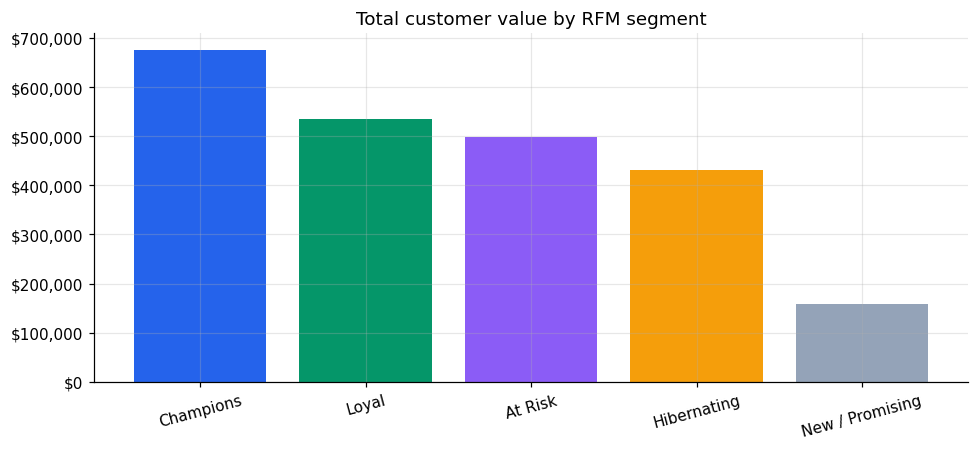

In [7]:
snapshot = df.order_date.max() + pd.Timedelta(days=1)
rfm = df.groupby("customer_id").agg(
    recency=("order_date", lambda s: (snapshot - s.max()).days),
    frequency=("order_id", "nunique"),
    monetary=("sales", "sum"))
# Quintile scores (5 = best). rank() avoids duplicate-edge errors in qcut.
rfm["R"] = pd.qcut(rfm.recency.rank(method="first"), 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F"] = pd.qcut(rfm.frequency.rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M"] = pd.qcut(rfm.monetary.rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)

def segment(row):
    if row.R >= 4 and row.F >= 4: return "Champions"
    if row.R >= 3 and row.F >= 3: return "Loyal"
    if row.R >= 4 and row.F <= 2: return "New / Promising"
    if row.R <= 2 and row.F >= 3: return "At Risk"
    return "Hibernating"

rfm["segment"] = rfm.apply(segment, axis=1)
seg = (rfm.groupby("segment")
          .agg(customers=("segment", "size"), avg_spend=("monetary", "mean"),
               total_spend=("monetary", "sum"))
          .sort_values("total_spend", ascending=False))
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(seg.index, seg.total_spend, color=[ACCENT, GOOD, "#8b5cf6", "#f59e0b", MUTED][:len(seg)])
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.set_title("Total customer value by RFM segment")
plt.xticks(rotation=15)
fig.tight_layout(); fig.savefig("reports/figures/rfm_segments.png", bbox_inches="tight")
seg.round(0)

**Finding:** Champions and Loyal customers — a minority of the customer base —
account for the majority of revenue. Meanwhile the **At Risk** segment contains
previously-frequent buyers who have gone quiet: the highest-ROI target for a
win-back campaign, because their past behavior proves willingness to spend.

## Executive summary

| # | Finding | Recommended action |
|---|---------|--------------------|
| 1 | Margin is ~12% and flat while revenue grows | Shift reporting from revenue-first to profit-first |
| 2 | Tables / Bookcases / Supplies lose money | Reprice, renegotiate supply, or de-emphasize in promos |
| 3 | Profit collapses beyond 20% discount | Enforce a 20% discount ceiling without manager approval |
| 4 | A small RFM elite drives most value | Protect Champions (service tier), win back At Risk (targeted offers) |

*Tools: Python, pandas, matplotlib. Full methodology above — every number in
this summary is computed in this notebook and reproducible from the raw CSV.*